In [14]:
import torch

num_points = 20
num_features = 3
X = torch.rand(num_points, num_features)
print(X)
w = torch.rand(num_features)
print(w)
b = torch.rand(1)
print(b)
y = torch.matmul(X, w) + b + torch.randn(num_points)
y

tensor([[0.8959, 0.8365, 0.1691],
        [0.9724, 0.7151, 0.9143],
        [0.7744, 0.9533, 0.0532],
        [0.4773, 0.3545, 0.4271],
        [0.6736, 0.3419, 0.4315],
        [0.6039, 0.9046, 0.2561],
        [0.6595, 0.3344, 0.7938],
        [0.5066, 0.9248, 0.5664],
        [0.2231, 0.7635, 0.7531],
        [0.2016, 0.2732, 0.1744],
        [0.5885, 0.0115, 0.2672],
        [0.5395, 0.1419, 0.1895],
        [0.9026, 0.4399, 0.5633],
        [0.7497, 0.9089, 0.4921],
        [0.7470, 0.0068, 0.8461],
        [0.0056, 0.0835, 0.0606],
        [0.8190, 0.4502, 0.1725],
        [0.2631, 0.4578, 0.2337],
        [0.4024, 0.5214, 0.9007],
        [0.0676, 0.8206, 0.8835]])
tensor([0.6398, 0.7174, 0.1347])
tensor([0.5526])


tensor([ 2.2699, -0.1466,  1.1006,  1.2711,  0.8552,  1.3715,  1.7174,  2.0261,
         2.0459,  1.7092,  0.1426, -0.3400,  2.0945,  2.4116,  0.8924, -0.6792,
         0.7632, -0.0612,  0.6617,  0.6199])

In [15]:
import torch


def mcculloch_pitts_neuron(weights, inputs):
    weighted_sum = torch.dot(weights, inputs)
    output = torch.where(weighted_sum > 0, torch.tensor(1), torch.tensor(0))
    return output


# Define the weights and inputs
weights = torch.tensor([0.5, -0.5])
inputs = torch.tensor([1.0, 1.0])

# Compute the output of the neuron
output = mcculloch_pitts_neuron(weights, inputs)
print("Output of the McCulloch-Pitts neuron:", output)

Output of the McCulloch-Pitts neuron: tensor(0)


In [16]:
import torch


class McCullochPittsNeuron(torch.nn.Module):
    def __init__(self, weights, threshold):
        super(McCullochPittsNeuron, self).__init__()
        self.weights = torch.tensor(weights, dtype=torch.float32)
        self.threshold = threshold

    def forward(self, x):
        # Compute the weighted sum of inputs
        weighted_sum = torch.dot(x, self.weights)

        # Output 1 if the weighted sum is greater than or equal to the threshold, else output 0
        output = torch.where(
            weighted_sum >= self.threshold, torch.tensor(1), torch.tensor(0)
        )

        return output


# Example usage
# Define weights and threshold
weights = [0.5, -0.5]
threshold = 0

# Create a McCulloch-Pitts neuron
neuron = McCullochPittsNeuron(weights, threshold)

# Input example
input_data = torch.tensor([1.0, 0.0])

# Get the output of the neuron
output = neuron(input_data)

print("Output:", output.item())  # Output: 1 if the weighted sum >= threshold, else 0


Output: 1


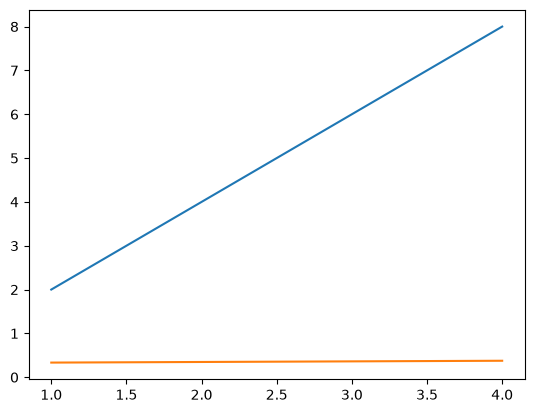

In [17]:
import torch
import matplotlib.pyplot as plt

# Sample data
X = torch.tensor([[1.0], [2.0], [3.0], [4.0]])  # Input data
y = torch.tensor([[2.0], [4.0], [6.0], [8.0]])  # Target data
# Model parameters
input_size = 1  # Input dimension
output_size = 1  # Output dimension
weights = torch.randn(input_size, output_size)  # random normal
bias = torch.randn(output_size)
prediction = torch.mm(X, weights) + bias  # dot product

plt.plot(X.detach(), y.detach())
plt.plot(X.detach(), prediction.detach())

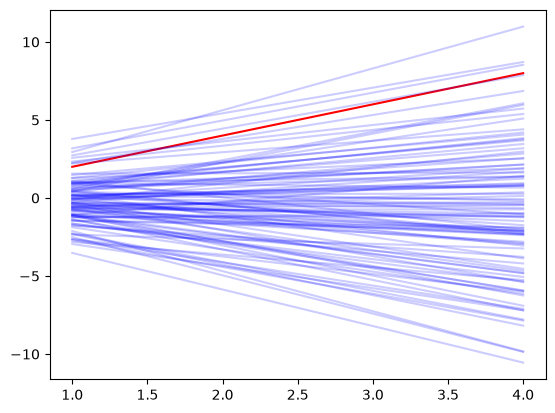

In [18]:
plt.plot(X.detach(), y.detach(), color="red")

for i in range(100):
    weights = torch.randn(input_size, output_size)
    bias = torch.randn(output_size)
    prediction = torch.mm(X, weights) + bias

    plt.plot(X.detach(), prediction.detach(), color="blue", alpha=0.2)

In [19]:
import torch

# Define variables with requires_grad=True to track computation history
a = torch.tensor(4.0, requires_grad=True)
b = torch.tensor(3.0, requires_grad=True)
# Define equations
c = a + b
d = a * c

# Compute gradients
d.backward()

# Access gradient of d w.r.t. a
d_da = a.grad

print("Gradient of d with respect to a:", d_da.item())

Gradient of d with respect to a: 11.0


In [20]:
import torch

# Sample data
X = torch.tensor([[1.0], [2.0], [3.0], [4.0]])  # Input data
y = torch.tensor([[2.0], [4.0], [6.0], [8.0]])  # Target data

# Model parameters
input_size = 1  # Input dimension
output_size = 1  # Output dimension
weights = torch.randn(input_size, output_size, requires_grad=True)
bias = torch.randn(output_size, requires_grad=True)

# Hyperparameters
learning_rate = 0.01
num_epochs = 5000

# Training loop
for epoch in range(num_epochs):
    # Forward pass
    outputs = torch.mm(X, weights) + bias  # Dot product + bias
    loss = torch.mean((outputs - y) ** 2)  # Mean Squared Error loss

    # Backward pass
    loss.backward()

    # Update weights and bias
    with torch.no_grad():
        weights -= learning_rate * weights.grad
        bias -= learning_rate * bias.grad

        # Manually zero the gradients after updating weights
        weights.grad.zero_()
        bias.grad.zero_()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}")


print(weights, bias)


Epoch [100/5000], Loss: 0.0933
Epoch [200/5000], Loss: 0.0512
Epoch [300/5000], Loss: 0.0281
Epoch [400/5000], Loss: 0.0154
Epoch [500/5000], Loss: 0.0085
Epoch [600/5000], Loss: 0.0047
Epoch [700/5000], Loss: 0.0026
Epoch [800/5000], Loss: 0.0014
Epoch [900/5000], Loss: 0.0008
Epoch [1000/5000], Loss: 0.0004
Epoch [1100/5000], Loss: 0.0002
Epoch [1200/5000], Loss: 0.0001
Epoch [1300/5000], Loss: 0.0001
Epoch [1400/5000], Loss: 0.0000
Epoch [1500/5000], Loss: 0.0000
Epoch [1600/5000], Loss: 0.0000
Epoch [1700/5000], Loss: 0.0000
Epoch [1800/5000], Loss: 0.0000
Epoch [1900/5000], Loss: 0.0000
Epoch [2000/5000], Loss: 0.0000
Epoch [2100/5000], Loss: 0.0000
Epoch [2200/5000], Loss: 0.0000
Epoch [2300/5000], Loss: 0.0000
Epoch [2400/5000], Loss: 0.0000
Epoch [2500/5000], Loss: 0.0000
Epoch [2600/5000], Loss: 0.0000
Epoch [2700/5000], Loss: 0.0000
Epoch [2800/5000], Loss: 0.0000
Epoch [2900/5000], Loss: 0.0000
Epoch [3000/5000], Loss: 0.0000
Epoch [3100/5000], Loss: 0.0000
Epoch [3200/5000]

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim


# Define a simple linear regression model
class LinearRegression(nn.Module):
    def __init__(self, input_size, output_size):
        super(LinearRegression, self).__init__()
        self.linear = nn.Linear(input_size, output_size)

    def forward(self, x):
        return self.linear(x)


# Initialize model
input_size = 1  # Input dimension
output_size = 1  # Output dimension
model = LinearRegression(input_size, output_size)

# Define loss function and optimizer
criterion = nn.MSELoss()  # Mean Squared Error loss
optimizer = optim.SGD(
    model.parameters(), lr=0.1
)  # Stochastic Gradient Descent optimizer

# Training loop
num_epochs = 1000
for epoch in range(num_epochs):
    # Forward pass
    outputs = model(X)
    loss = criterion(outputs, y)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}")

print(model.linear.weight)
print(model.linear.bias)


Epoch [100/1000], Loss: 0.0007
Epoch [200/1000], Loss: 0.0000
Epoch [300/1000], Loss: 0.0000
Epoch [400/1000], Loss: 0.0000
Epoch [500/1000], Loss: 0.0000
Epoch [600/1000], Loss: 0.0000
Epoch [700/1000], Loss: 0.0000
Epoch [800/1000], Loss: 0.0000
Epoch [900/1000], Loss: 0.0000
Epoch [1000/1000], Loss: 0.0000
Parameter containing:
tensor([[2.]], requires_grad=True)
Parameter containing:
tensor([1.1359e-07], requires_grad=True)


In [22]:
# Define a simple linear model
class LinearModel(nn.Module):
    def __init__(self, input_size, output_size):
        super(LinearModel, self).__init__()
        self.linear = nn.Linear(input_size, output_size)

    def forward(self, x):
        return self.linear(x)


# Define a neural network by stacking linear models
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(NeuralNetwork, self).__init__()
        self.layer1 = LinearModel(input_size, hidden_size)
        self.layer2 = LinearModel(hidden_size, output_size)

    def forward(self, x):
        x = self.layer1(x)
        x = torch.relu(x)  # Applying activation
        x = self.layer2(x)
        return x

In [23]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
input_size = 784  # 28 x 28 pixels
num_classes = 10
num_epochs = 5
batch_size = 100
learning_rate = 0.001

# MNIST dataset
train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, transform=transforms.ToTensor(), download=True
)

test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, transform=transforms.ToTensor()
)

# Data loader
train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset, batch_size=batch_size, shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset, batch_size=batch_size, shuffle=False
)


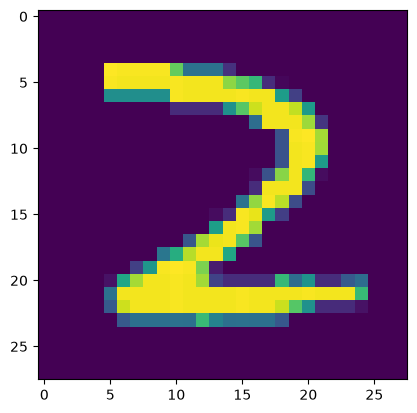

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)
plt.imshow(images[5, 0, :, :])


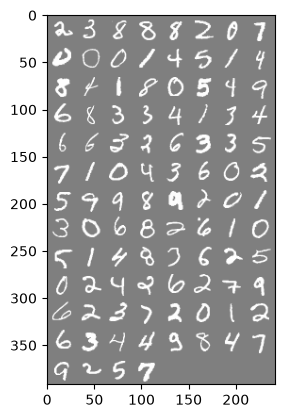

In [25]:
# Function to show an image
def imshow(img):
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# Show images
imshow(torchvision.utils.make_grid(images))


In [26]:
# Fully connected neural network with one hidden layer
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.reshape(x.size(0), -1)
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out


hidden_size = 256
model = NeuralNet(input_size, hidden_size, num_classes).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Train the model
total_step = len(train_loader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i + 1) % 100 == 0:
            print(
                "Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}".format(
                    epoch + 1, num_epochs, i + 1, total_step, loss.item()
                )
            )

# Test the model
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(
        "Accuracy of the network on the 10000 test images: {} %".format(
            100 * correct / total
        )
    )

Epoch [1/5], Step [100/600], Loss: 0.5821
Epoch [1/5], Step [200/600], Loss: 0.3059
Epoch [1/5], Step [300/600], Loss: 0.2859
Epoch [1/5], Step [400/600], Loss: 0.1536
Epoch [1/5], Step [500/600], Loss: 0.1859
Epoch [1/5], Step [600/600], Loss: 0.2040
Epoch [2/5], Step [100/600], Loss: 0.0883
Epoch [2/5], Step [200/600], Loss: 0.1690
Epoch [2/5], Step [300/600], Loss: 0.2394
Epoch [2/5], Step [400/600], Loss: 0.0806
Epoch [2/5], Step [500/600], Loss: 0.1270
Epoch [2/5], Step [600/600], Loss: 0.0899
Epoch [3/5], Step [100/600], Loss: 0.0884
Epoch [3/5], Step [200/600], Loss: 0.2107
Epoch [3/5], Step [300/600], Loss: 0.0897
Epoch [3/5], Step [400/600], Loss: 0.1413
Epoch [3/5], Step [500/600], Loss: 0.1368
Epoch [3/5], Step [600/600], Loss: 0.0318
Epoch [4/5], Step [100/600], Loss: 0.0656
Epoch [4/5], Step [200/600], Loss: 0.0271
Epoch [4/5], Step [300/600], Loss: 0.1538
Epoch [4/5], Step [400/600], Loss: 0.0693
Epoch [4/5], Step [500/600], Loss: 0.0597
Epoch [4/5], Step [600/600], Loss: